# CatBoost Swing Trading Model
Multi-class classifier (`-1` / `0` / `1`) trained on Triple Barrier labels.

| Label | Meaning |
|---|---|
| `1` | Take-Profit hit within horizon |
| `-1` | Stop-Loss hit within horizon |
| `0` | Time expiry — neither barrier reached |

**Panel dataset** — 50 tickers stacked vertically, features computed per-ticker via `.groupby('Ticker')` to prevent cross-contamination. Evaluation uses a strict chronological split (no random shuffling).

## Cell 1 — Setup & Data Loading

In [15]:
import os
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------------------------------
# Path constants
# ---------------------------------------------------------------------------
LABELED_DIR: str = "data/labeled"
MODEL_DIR: str = "data/models"

os.makedirs(MODEL_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Load & stack all labeled CSVs into a single panel DataFrame
# ---------------------------------------------------------------------------
files: list[str] = sorted(glob(os.path.join(LABELED_DIR, "*_labeled.csv")))

if not files:
    raise FileNotFoundError(
        f"No labeled CSVs found in '{LABELED_DIR}'. "
        "Run label_generator.ipynb first."
    )

frames: list[pd.DataFrame] = []
for path in files:
    ticker: str = os.path.basename(path).replace("_labeled.csv", "")
    df: pd.DataFrame = pd.read_csv(path, parse_dates=["Date"])
    df["Ticker"] = ticker
    frames.append(df)

master: pd.DataFrame = (
    pd.concat(frames, ignore_index=True)
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
)

print(f"Loaded {len(files)} tickers  |  master shape: {master.shape}")
print(f"Date range : {master['Date'].min().date()} → {master['Date'].max().date()}")
print(f"Target dist:\n{master['Target'].value_counts().sort_index()}")

Loaded 49 tickers  |  master shape: (23862, 19)
Date range : 2024-05-08 → 2026-04-30
Target dist:
Target
-1     8978
 0     4852
 1    10032
Name: count, dtype: int64


## Cell 2 — Feature Engineering (Grouped by Ticker)

All rolling windows and percent-change operations are applied **inside** `.groupby('Ticker')`
to prevent cross-ticker contamination.  Every feature is computed on data that would have
been observable *before* the close of bar `i` — no lookahead.

| Feature | Description |
|---|---|
| `Price_Pct_Change_1D` | 1-day `adjusted_close` return |
| `Vol_Pct_Change_1D` | 1-day `volume` change |
| `Article_Count_Change` | 1-day diff in `article_count` |
| `SPY_Pct_Change_3D` | 3-day SPY return (market regime) |
| `Overnight_Gap_ES` | `(ESF_Close − prev_close) / prev_close` — macro gap |
| `Sentiment_Momentum` | `avg_sentiment − 3-day rolling mean` |
| `RSI_14` | 14-day Wilder RSI |
| `Distance_from_20SMA` | `(close / 20-day SMA) − 1` |

In [16]:
def _rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    Compute Wilder's RSI for a price series.

    Uses exponential moving average (Wilder smoothing, com = period - 1)
    rather than simple rolling mean to match standard RSI definitions.

    Parameters
    ----------
    series : pd.Series
        Raw price series (e.g. adjusted_close) for a single ticker,
        already sorted chronologically.
    period : int
        Lookback window (default 14).

    Returns
    -------
    pd.Series
        RSI values in [0, 100].
    """
    delta: pd.Series = series.diff()
    gain: pd.Series = delta.clip(lower=0)
    loss: pd.Series = (-delta).clip(lower=0)

    avg_gain: pd.Series = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss: pd.Series = loss.ewm(com=period - 1, min_periods=period).mean()

    rs: pd.Series = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute all predictive features on the panel DataFrame.

    Every operation is applied inside .groupby('Ticker') so that rolling
    windows never bleed across ticker boundaries.

    Parameters
    ----------
    df : pd.DataFrame
        Master panel DataFrame with columns from the labeled CSVs plus
        a 'Ticker' column.

    Returns
    -------
    pd.DataFrame
        Original DataFrame with engineered feature columns appended.
        Rows containing NaNs introduced by rolling windows are dropped.
    """
    grp = df.groupby("Ticker", group_keys=False)

    # 1-day adjusted_close return
    df["Price_Pct_Change_1D"] = grp["adjusted_close"].transform(
        lambda s: s.pct_change(1)
    )

    # 3-day SPY return (market regime context)
    df["SPY_Pct_Change_3D"] = grp["SPY_AdjClose"].transform(
        lambda s: s.pct_change(3)
    )

    # Overnight macro gap: ES futures vs prior close
    # (ESF_Close at bar i reflects the futures price after the equity close,
    # so dividing by the prior adjusted_close gives an overnight gap proxy.)
    df["Overnight_Gap_ES"] = grp.apply(
        lambda g: (g["ESF_Close"] - g["adjusted_close"].shift(1))
                  / g["adjusted_close"].shift(1)
    ).reset_index(level=0, drop=True)

    # RSI-14
    df["RSI_14"] = grp["adjusted_close"].transform(_rsi)

    # Distance from 20-day SMA (0 = at SMA, positive = above)
    df["Distance_from_20SMA"] = grp["adjusted_close"].transform(
        lambda s: (s / s.rolling(20).mean()) - 1
    )

    # Drop NaN rows created by rolling windows (no imputation for price features)
    df = df.dropna().reset_index(drop=True)
    return df


featured: pd.DataFrame = engineer_features(master.copy())

ENGINEERED_COLS: list[str] = [
    "Price_Pct_Change_1D", "SPY_Pct_Change_3D", "Overnight_Gap_ES",
    "RSI_14", "Distance_from_20SMA",
]

print(f"Post-engineering shape : {featured.shape}")
print(f"Remaining NaNs         : {featured[ENGINEERED_COLS].isna().sum().sum()}")
featured[ENGINEERED_COLS].describe().round(4)

Post-engineering shape : (22931, 24)
Remaining NaNs         : 0


/var/folders/1f/5lhk7sb97rz53v7gk1vkcjkr0000gn/T/ipykernel_2373/431240314.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["Overnight_Gap_ES"] = grp.apply(


,Price_Pct_Change_1D,SPY_Pct_Change_3D,Overnight_Gap_ES,RSI_14,Distance_from_20SMA
count,22931.0000,22931.0000,22931.0000,22931.0000,22931.0000
mean,0.0013,0.0020,128.0769,51.8138,0.0075
std,0.0353,0.0178,414.2930,12.8651,0.0845
min,-0.3332,-0.1065,2.7240,14.3870,-0.4661
25%,-0.0150,-0.0068,23.1376,42.4742,-0.0410
50%,0.0010,0.0037,34.9709,51.4762,0.0067
75%,0.0168,0.0114,68.8111,60.9848,0.0533
max,0.3796,0.0858,6764.3207,90.3542,0.6562


## Cell 3 — Chronological Train / Test Split

The split is made on the **global date axis** — the first 75 % of unique trading days
form the training set; the last 25 % form the out-of-sample test set.
This preserves temporal ordering across all tickers simultaneously and prevents
any future bar from leaking into the training window.

In [ ]:
TRAIN_RATIO: float = 0.75

# Explicit allowlist — only these columns are fed to the model.
# Using an allowlist (rather than a drop-list) makes the feature surface
# unambiguous and prevents accidental leakage if new columns are added upstream.
FEATURE_COLS: list[str] = [
    # Technical / price-derived (relative, no lookahead)
    "Price_Pct_Change_1D",
    "SPY_Pct_Change_3D",
    "Overnight_Gap_ES",
    "RSI_14",
    "Distance_from_20SMA",
    # Sentiment (raw Alpha Vantage aggregates)
    "avg_sentiment",
    "weighted_avg_sentiment",
]

# ---------------------------------------------------------------------------
# Chronological split on the global date axis
# ---------------------------------------------------------------------------
sorted_dates: np.ndarray = np.sort(featured["Date"].unique())
split_idx: int = int(len(sorted_dates) * TRAIN_RATIO)
cutoff_date: pd.Timestamp = pd.Timestamp(sorted_dates[split_idx])

train_mask: pd.Series = featured["Date"] < cutoff_date
test_mask: pd.Series  = featured["Date"] >= cutoff_date

train_df: pd.DataFrame = featured[train_mask].copy()
test_df: pd.DataFrame  = featured[test_mask].copy()

# ---------------------------------------------------------------------------
# Gracefully drop any allowlisted columns that don't exist in the data yet
# (e.g. weighted_avg_sentiment is absent from labeled files generated before
# the merger was updated — re-run data_merger + label_generator to restore it).
# ---------------------------------------------------------------------------
missing: list[str] = [c for c in FEATURE_COLS if c not in featured.columns]
if missing:
    print(f"[WARN] Columns not found in data, skipping: {missing}")
    print("       Re-run data_merger.ipynb → label_generator.ipynb to include them.")

feature_cols: list[str] = [c for c in FEATURE_COLS if c in featured.columns]

X_train: pd.DataFrame = train_df[feature_cols]
y_train: pd.Series    = train_df["Target"]

X_test: pd.DataFrame  = test_df[feature_cols]
y_test: pd.Series     = test_df["Target"]

print(f"Train cutoff   : {cutoff_date.date()}")
print(f"Train set      : {len(X_train):>6} rows  ({train_mask.mean():.0%} of data)")
print(f"Test  set      : {len(X_test):>6} rows  ({test_mask.mean():.0%} of data)")
print(f"Feature cols   : {feature_cols}")
print(f"\nTrain target dist:\n{y_train.value_counts().sort_index()}")
print(f"\nTest  target dist:\n{y_test.value_counts().sort_index()}")

KeyError: "The following required feature columns are missing: ['weighted_avg_sentiment']"

## Cell 4 — CatBoost Training

`auto_class_weights='Balanced'` compensates for the heavy class-0 majority without
manually computing class weights.  Early stopping monitors the test eval set loss
and halts training if no improvement is seen for 50 rounds.

In [ ]:
MODEL_PATH: str = os.path.join(MODEL_DIR, "catboost_swing_v1.cbm")

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100,
)

train_pool = Pool(X_train, y_train)
eval_pool  = Pool(X_test,  y_test)

model.fit(
    train_pool,
    eval_set=eval_pool,
    early_stopping_rounds=50,
    use_best_model=True,
)

model.save_model(MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")
print(f"Best iteration : {model.get_best_iteration()}")

0:	learn: 0.4237605	test: 0.3719739	best: 0.3719739 (0)	total: 3.14ms	remaining: 3.14s
100:	learn: 0.4831440	test: 0.3859606	best: 0.3886073 (92)	total: 273ms	remaining: 2.43s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3886073384
bestIteration = 92

Shrink model to first 93 iterations.

Model saved to: data/models/catboost_swing_v1.cbm
Best iteration : 92


## Cell 5 — Evaluation & Feature Importance

OUT-OF-SAMPLE CLASSIFICATION REPORT
              precision    recall  f1-score   support

     SL (-1)       0.48      0.33      0.39      2635
  Expiry (0)       0.23      0.53      0.32       934
      TP (1)       0.42      0.36      0.39      2288

    accuracy                           0.37      5857
   macro avg       0.38      0.41      0.37      5857
weighted avg       0.42      0.37      0.38      5857



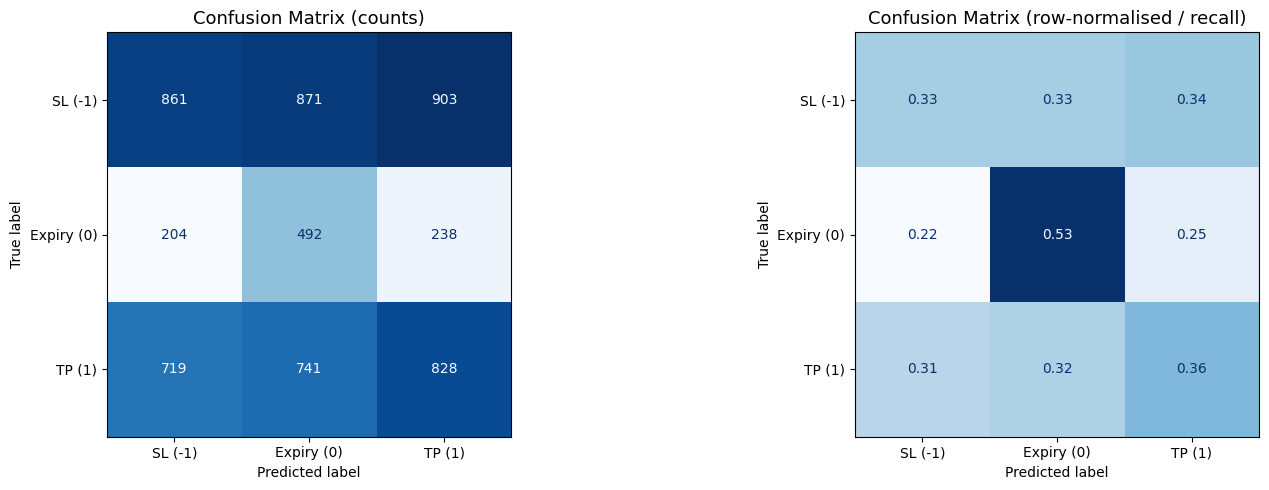

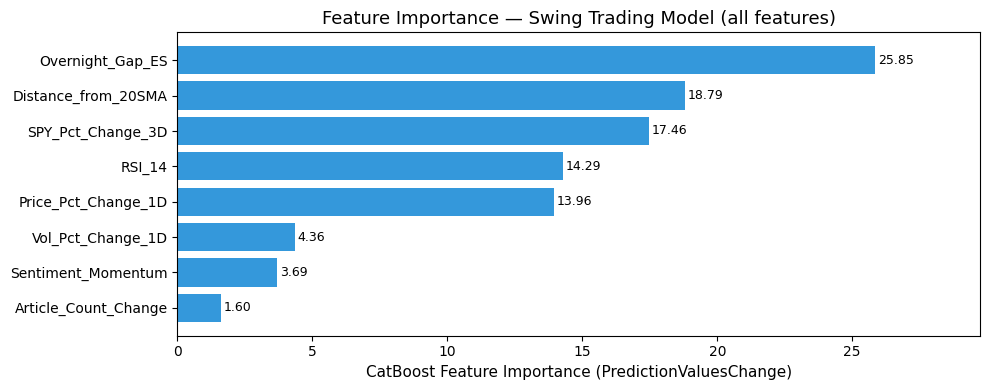


Feature Importance — Full Ranked Table
 Rank              Feature  Importance  Pct_of_Total
    1     Overnight_Gap_ES     25.8541         25.85
    2  Distance_from_20SMA     18.7887         18.79
    3    SPY_Pct_Change_3D     17.4578         17.46
    4               RSI_14     14.2850         14.29
    5  Price_Pct_Change_1D     13.9578         13.96
    6    Vol_Pct_Change_1D      4.3634          4.36
    7   Sentiment_Momentum      3.6917          3.69
    8 Article_Count_Change      1.6014          1.60


In [ ]:
y_pred: np.ndarray = model.predict(X_test).flatten().astype(int)
CLASS_LABELS: list[int] = [-1, 0, 1]
CLASS_NAMES: list[str]  = ["SL (-1)", "Expiry (0)", "TP (1)"]

# ---------------------------------------------------------------------------
# Classification report
# ---------------------------------------------------------------------------
print("=" * 60)
print("OUT-OF-SAMPLE CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, labels=CLASS_LABELS, target_names=CLASS_NAMES))

# ---------------------------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (counts)", fontsize=13)

# Normalised confusion matrix (recall per true class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2), display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix (row-normalised / recall)", fontsize=13)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Feature importance — horizontal bar chart (all features, uniform colour)
# ---------------------------------------------------------------------------
importances: np.ndarray = model.get_feature_importance()
fi_df: pd.DataFrame = (
    pd.DataFrame({"Feature": feature_cols, "Importance": importances})
    .sort_values("Importance", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(fi_df) * 0.45)))
ax.barh(fi_df["Feature"], fi_df["Importance"], color="#3498db")
for i, (imp, feat) in enumerate(zip(fi_df["Importance"], fi_df["Feature"])):
    ax.text(imp + 0.1, i, f"{imp:.2f}", va="center", fontsize=9)
ax.set_xlabel("CatBoost Feature Importance (PredictionValuesChange)", fontsize=11)
ax.set_title("Feature Importance — Swing Trading Model (all features)", fontsize=13)
ax.set_xlim(0, fi_df["Importance"].max() * 1.15)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Ranked importance table — every feature with its exact value
# ---------------------------------------------------------------------------
ranked: pd.DataFrame = (
    fi_df.sort_values("Importance", ascending=False)
    .reset_index(drop=True)
    .rename_axis("Rank")
    .reset_index()
)
ranked["Rank"] += 1
ranked["Importance"] = ranked["Importance"].round(4)
ranked["Pct_of_Total"] = (ranked["Importance"] / ranked["Importance"].sum() * 100).round(2)

print("\nFeature Importance — Full Ranked Table")
print("=" * 50)
print(ranked[["Rank", "Feature", "Importance", "Pct_of_Total"]].to_string(index=False))